In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
df = pd.read_csv("../data/clean_reviews.csv")
df.head()
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (555, 17)
<class 'pandas.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   review_id            555 non-null    int64  
 1   item_name            555 non-null    str    
 2   review_text          555 non-null    str    
 3   rating               555 non-null    float64
 4   review_date          555 non-null    str    
 5   helpful_votes        555 non-null    int64  
 6   total_votes          555 non-null    int64  
 7   helpfulness_score    555 non-null    float64
 8   helpful_label        555 non-null    int64  
 9   source               555 non-null    str    
 10  review_url           555 non-null    str    
 11  clean_text           555 non-null    str    
 12  tokens               555 non-null    str    
 13  processed_text       555 non-null    str    
 14  text_length          555 non-null    int64  
 15  word_count           555 non-null 

,review_id,rating,helpful_votes,total_votes,helpfulness_score,helpful_label,text_length,word_count,original_word_count
count,555.000000,555.000000,555.000000,555.000000,555.000000,555.000000,555.000000,555.000000,555.000000
mean,322.066667,1.232432,225.239640,226.239640,0.231964,0.472072,331.603604,54.311712,110.479279
std,191.054609,0.789160,292.505432,292.505432,0.301244,0.499670,465.345237,75.802506,150.425957
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,12.000000,3.000000,4.000000
25%,156.500000,1.000000,0.000000,1.000000,0.000000,0.000000,67.500000,12.000000,25.000000
50%,320.000000,1.000000,0.000000,1.000000,0.000000,0.000000,157.000000,27.000000,57.000000
75%,486.500000,1.000000,446.500000,447.500000,0.459500,1.000000,413.000000,67.000000,132.000000
max,654.000000,5.000000,971.000000,972.000000,1.000000,1.000000,3870.000000,634.000000,1153.000000


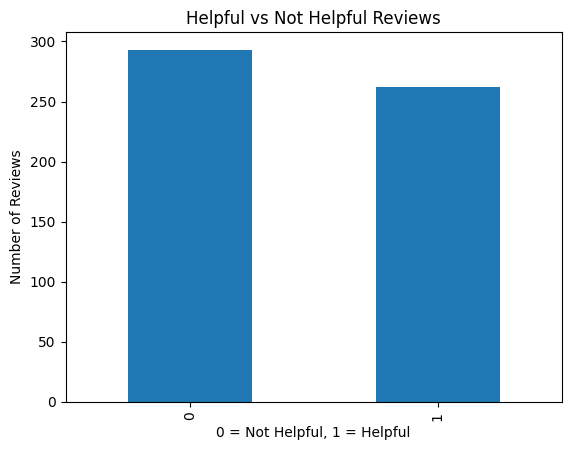

In [3]:
df["helpful_label"].value_counts().sort_index().plot(kind="bar")
plt.title("Helpful vs Not Helpful Reviews")
plt.xlabel("0 = Not Helpful, 1 = Helpful")
plt.ylabel("Number of Reviews")
plt.show()


Reviews Per Game:
item_name
Booking             60
PUBG                59
Temu                59
AliExpress          59
Shein               58
Amazon              57
Apex Legends        55
Dota 2              54
Counter Strike 2    53
Team Fortress 2     41
Name: count, dtype: int64


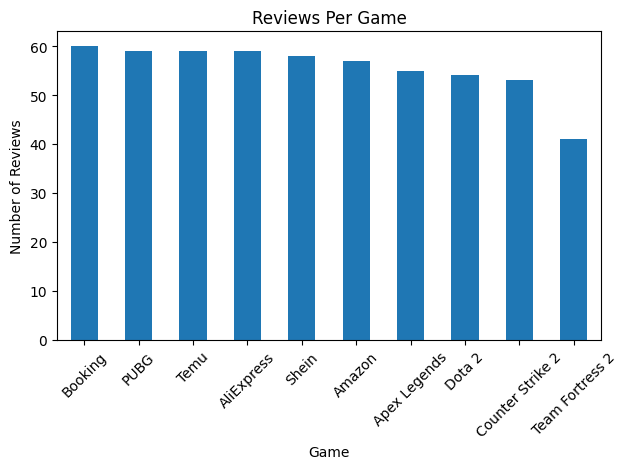

In [4]:
print("\nReviews Per Game:")
print(df["item_name"].value_counts())

df["item_name"].value_counts().plot(kind="bar")
plt.title("Reviews Per Game")
plt.xlabel("Game")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Rating Distribution:
rating
1.0    500
3.0     18
2.0     16
5.0     14
4.0      7
Name: count, dtype: int64


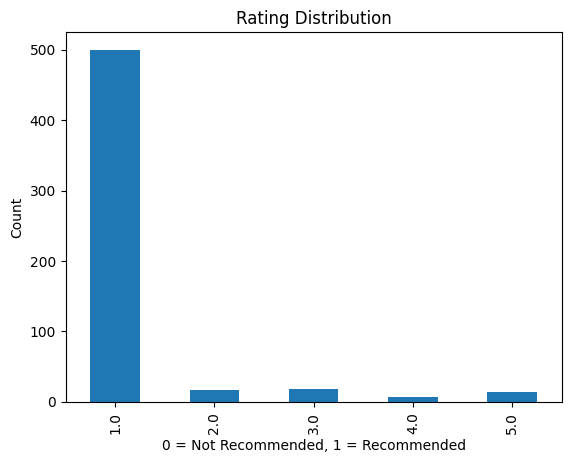

In [7]:
#rec w not
print("\nRating Distribution:")
print(df["rating"].value_counts())
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("0 = Not Recommended, 1 = Recommended")
plt.ylabel("Count")
plt.show()


Text Length Statistics:
count     555.000000
mean      331.603604
std       465.345237
min        12.000000
25%        67.500000
50%       157.000000
75%       413.000000
max      3870.000000
Name: text_length, dtype: float64


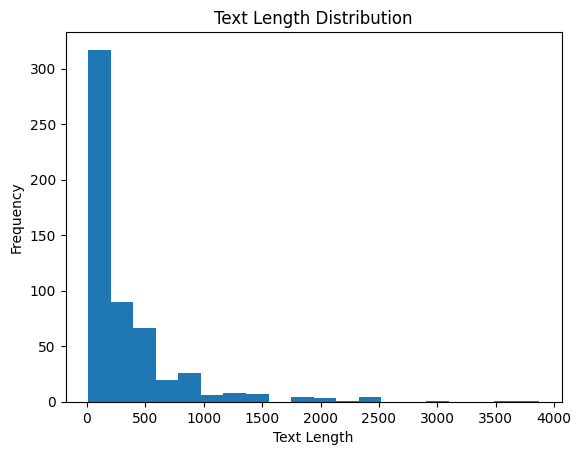

In [8]:
print("\nText Length Statistics:")
print(df["text_length"].describe())

df["text_length"].plot(kind="hist", bins=20)
plt.title("Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()


Word Count Statistics:
count    555.000000
mean      54.311712
std       75.802506
min        3.000000
25%       12.000000
50%       27.000000
75%       67.000000
max      634.000000
Name: word_count, dtype: float64


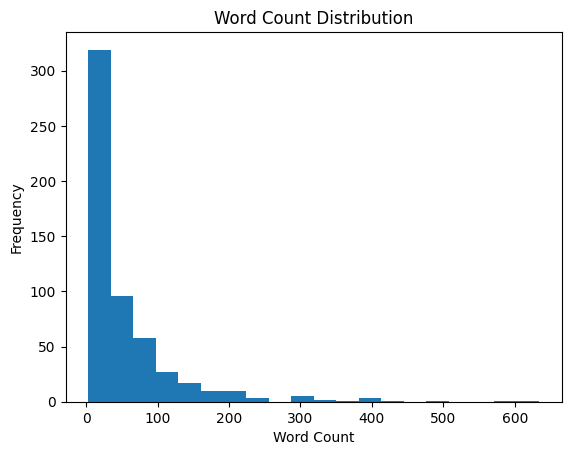

In [9]:
print("\nWord Count Statistics:")
print(df["word_count"].describe())

df["word_count"].plot(kind="hist", bins=20)
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


Average Text Length by Helpfulness:
helpful_label
0    321.808874
1    342.557252
Name: text_length, dtype: float64


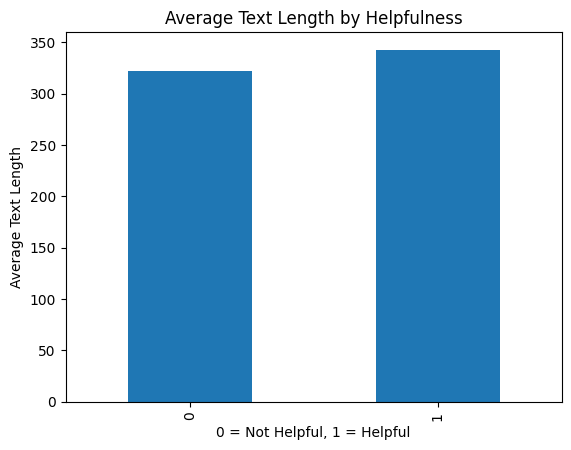

In [10]:
print("\nAverage Text Length by Helpfulness:")
print(df.groupby("helpful_label")["text_length"].mean())

df.groupby("helpful_label")["text_length"].mean().plot(kind="bar")
plt.title("Average Text Length by Helpfulness")
plt.xlabel("0 = Not Helpful, 1 = Helpful")
plt.ylabel("Average Text Length")
plt.show()


Average Word Count by Helpfulness:
helpful_label
0    51.795222
1    57.125954
Name: word_count, dtype: float64


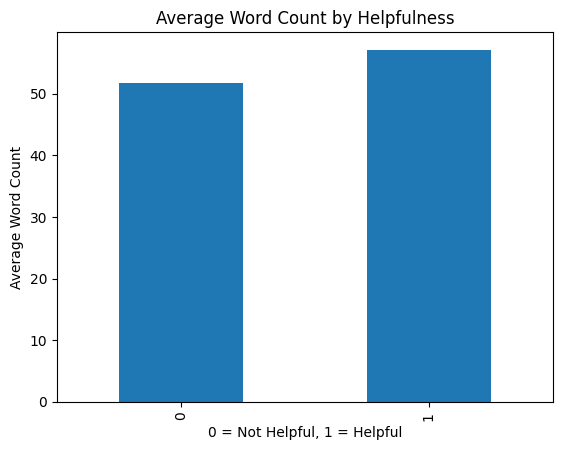

In [11]:
print("\nAverage Word Count by Helpfulness:")
print(df.groupby("helpful_label")["word_count"].mean())

df.groupby("helpful_label")["word_count"].mean().plot(kind="bar")
plt.title("Average Word Count by Helpfulness")
plt.xlabel("0 = Not Helpful, 1 = Helpful")
plt.ylabel("Average Word Count")
plt.show()

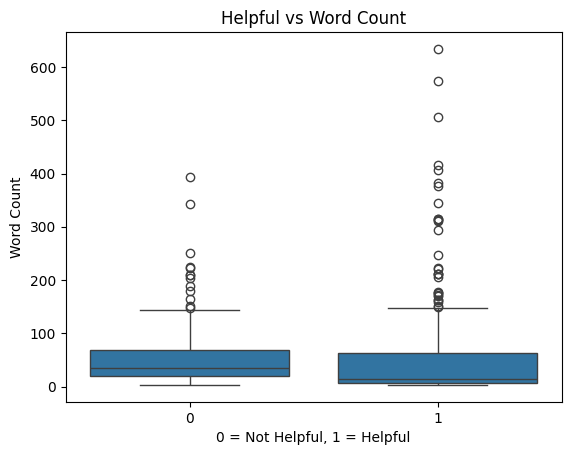

In [12]:
sns.boxplot(x="helpful_label", y="word_count", data=df)
plt.title("Helpful vs Word Count")
plt.xlabel("0 = Not Helpful, 1 = Helpful")
plt.ylabel("Word Count")
plt.show()


Correlation Matrix:
                     rating  helpful_votes  total_votes  helpfulness_score  \
rating             1.000000      -0.227209    -0.227209          -0.227205   
helpful_votes     -0.227209       1.000000     1.000000           1.000000   
total_votes       -0.227209       1.000000     1.000000           1.000000   
helpfulness_score -0.227205       1.000000     1.000000           1.000000   
helpful_label     -0.278766       0.815053     0.815053           0.815037   
text_length       -0.114998       0.033940     0.033940           0.033943   
word_count        -0.116330       0.044990     0.044990           0.044993   

                   helpful_label  text_length  word_count  
rating                 -0.278766    -0.114998   -0.116330  
helpful_votes           0.815053     0.033940    0.044990  
total_votes             0.815053     0.033940    0.044990  
helpfulness_score       0.815037     0.033943    0.044993  
helpful_label           1.000000     0.022279    0.035

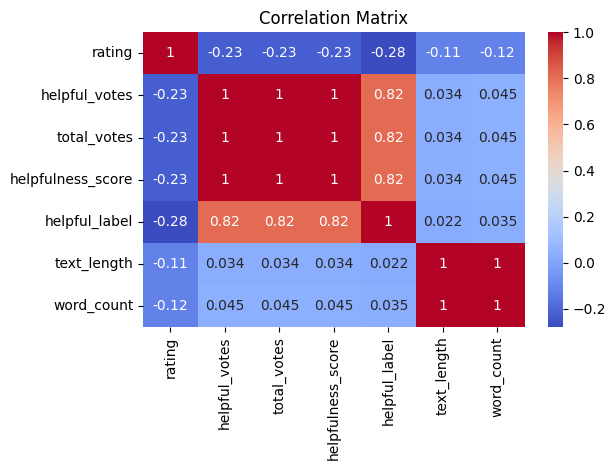

In [13]:
numeric_cols = [
    "rating",
    "helpful_votes",
    "total_votes",
    "helpfulness_score",
    "helpful_label",
    "text_length",
    "word_count"
]

corr = df[numeric_cols].corr()

print("\nCorrelation Matrix:")
print(corr)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


Top 20 Frequent Words:
[('game', 619), ('time', 247), ('play', 232), ('book', 218), ('refund', 212), ('order', 210), ('get', 201), ('custom', 194), ('like', 187), ('one', 183), ('item', 177), ('servic', 161), ('return', 159), ('would', 155), ('receiv', 145), ('still', 138), ('player', 137), ('day', 136), ('use', 134), ('even', 131)]


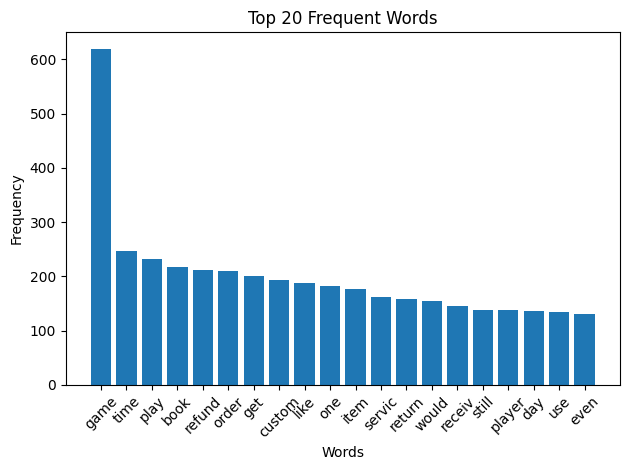

In [14]:
all_words = " ".join(df["processed_text"].astype(str)).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

print("\nTop 20 Frequent Words:")
print(common_words)
words = [x[0] for x in common_words]
counts = [x[1] for x in common_words]
plt.bar(words, counts)
plt.title("Top 20 Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()